# 03_mitigate.ipynb — Fairness + Privacy Mitigation

This notebook demonstrates how we reduce bias while adding privacy protections to the debiased model.

We use:
- Fairlearn ExponentiatedGradient with a Demographic Parity fairness constraint
- A differentially private logistic regression base estimator (DP-style training)
- Data minimization by dropping encoded gender/race/zip feature columns from model inputs
- Group-wise fairness metrics to compare baseline vs debiased predictions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate

import joblib
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("../data/loan_dataset.csv")
df = df.drop(columns=["ID"], errors="ignore")
df = df.dropna()

# Encode categorical vars
df_enc = pd.get_dummies(df, drop_first=True)

X = df_enc.drop(columns=["loan_approved"], errors="ignore")
y = df["loan_approved"].map({"Denied": 0, "Approved": 1})

print(f"✅ Dataset loaded: {X.shape[0]} rows, {X.shape[1]} features")


✅ Dataset loaded: 10000 rows, 31 features


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

lr = LogisticRegression(solver="liblinear")
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"📊 Baseline Accuracy: {acc:.4f}")


📊 Baseline Accuracy: 0.5817


In [12]:
# ✅ Step 1: Prepare df_test with predictions and original sensitive features
df_test = X_test.copy()
df_test["y_true"] = y_test
df_test["y_pred"] = y_pred

# ✅ Step 2: Attach original sensitive features (aligned by index)
# Ensure all features are pulled in, including age_group & zip_code_group
sensitive_cols = ["gender", "race", "age_group", "zip_code_group"]
df_test = df_test.merge(df[sensitive_cols], left_index=True, right_index=True, how="left")

# ✅ Step 3: Confirm required sensitive features exist
print("✅ Sensitive columns in df_test:", df_test.columns.intersection(sensitive_cols).tolist())

# ✅ Step 4: Create fairness MetricFrame for gender (baseline)
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score

mf = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
        "fpr": false_positive_rate,
        "fnr": false_negative_rate
    },
    y_true=df_test["y_true"],
    y_pred=df_test["y_pred"],
    sensitive_features=df_test["gender"]
)

print("⚖️ Baseline Fairness Metrics (by gender):")
display(mf.by_group)


✅ Sensitive columns in df_test: ['gender', 'race', 'age_group', 'zip_code_group']
⚖️ Baseline Fairness Metrics (by gender):


,accuracy,selection_rate,fpr,fnr
gender,,,,
Female,0.588433,0.258238,0.219429,0.686275
Male,0.577503,0.262689,0.211321,0.675716
Non-binary,0.509091,0.290909,0.333333,0.789474


In [ ]:
import os
import sys

# Make src importable when running from notebooks/
sys.path.append(os.path.abspath(".."))

from src.dp_logistic_regression import DPLogisticRegression

# Use original sensitive attribute for fairness constraint
sensitive_attr = df.loc[X_train.index, "gender"]

# Data minimization: drop encoded sensitive/proxy columns from model inputs
sensitive_prefixes = ("gender_", "race_", "zip_code_group_")
cols_to_drop = [c for c in X_train.columns if c.startswith(sensitive_prefixes)]
X_train_min = X_train.drop(columns=cols_to_drop, errors="ignore")
X_test_min = X_test.drop(columns=cols_to_drop, errors="ignore")
print(f"🧹 Dropped {len(cols_to_drop)} encoded sensitive/proxy columns")

# Debiased + private model
mitigator = ExponentiatedGradient(
    estimator=DPLogisticRegression(epsilon=8.0, epochs=300, random_state=42),
    constraints=DemographicParity()
 )

mitigator.fit(X_train_min, y_train, sensitive_features=sensitive_attr)
y_pred_fair = mitigator.predict(X_test_min)

In [6]:
acc_fair = accuracy_score(y_test, y_pred_fair)
print(f"✅ Debiased Accuracy: {acc_fair:.4f}")

df_test["y_pred_fair"] = y_pred_fair

mf_fair = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
        "fpr": false_positive_rate,
        "fnr": false_negative_rate
    },
    y_true=df_test["y_true"],
    y_pred=df_test["y_pred_fair"],
    sensitive_features=df_test["gender"]
)

print("⚖️ Debiased Fairness Metrics (by gender):")
display(mf_fair.by_group)


✅ Debiased Accuracy: 0.5937
⚖️ Debiased Fairness Metrics (by gender):


,accuracy,selection_rate,fpr,fnr
gender,,,,
Female,0.595831,0.258911,0.213714,0.676471
Male,0.593964,0.262689,0.196226,0.657617
Non-binary,0.527273,0.272727,0.305556,0.789474


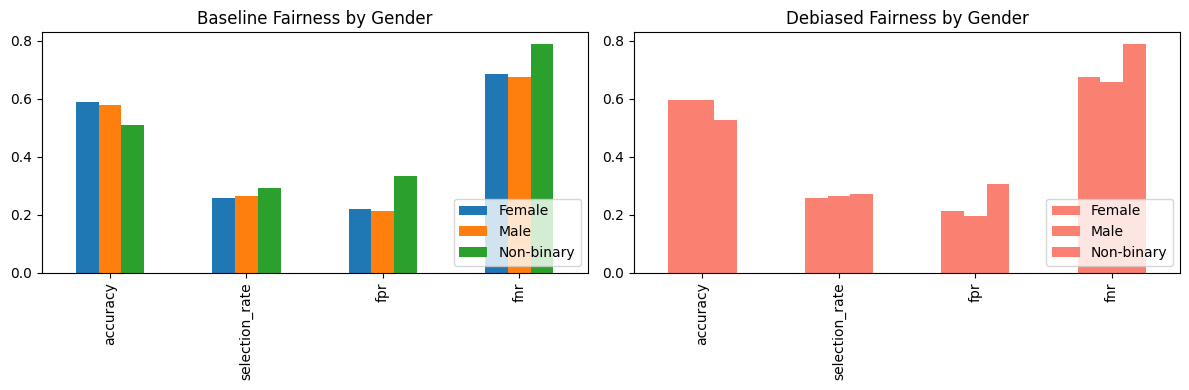

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

mf.by_group.T.plot(kind="bar", ax=ax[0])
ax[0].set_title("Baseline Fairness by Gender")
ax[0].legend(loc="lower right")

mf_fair.by_group.T.plot(kind="bar", color="salmon", ax=ax[1])
ax[1].set_title("Debiased Fairness by Gender")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(mitigator, "results/model_debiased_xgb.pkl")
joblib.dump(list(X_train_min.columns), "results/debiased_model_features.pkl")

print("✅ Debiased privacy-aware model and features saved.")

✅ Debiased model and features saved.


In [13]:
# Mitigate for age_group
sensitive_attr_age = df.loc[X_train.index, "age_group"]

mitigator_age = ExponentiatedGradient(
    estimator=LogisticRegression(solver="liblinear"),
    constraints=DemographicParity()
)
mitigator_age.fit(X_train, y_train, sensitive_features=sensitive_attr_age)
y_pred_age_fair = mitigator_age.predict(X_test)

acc_age_fair = accuracy_score(y_test, y_pred_age_fair)
print(f"✅ Debiased Accuracy (Age Group): {acc_age_fair:.4f}")

df_test["y_pred_age_fair"] = y_pred_age_fair

mf_age_fair = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
        "fpr": false_positive_rate,
        "fnr": false_negative_rate
    },
    y_true=df_test["y_true"],
    y_pred=df_test["y_pred_age_fair"],
    sensitive_features=df_test["age_group"]
)
display(mf_age_fair.by_group)


✅ Debiased Accuracy (Age Group): 0.5717


,accuracy,selection_rate,fpr,fnr
age_group,,,,
25-60,0.565378,0.242480,0.214130,0.720733
Over 60,0.577410,0.218111,0.180243,0.733333
Under 25,0.584302,0.255814,0.229665,0.703704


In [14]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score

# Reuse the original df and X_train
sensitive_attr_age = df.loc[X_train.index, "age_group"]

mitigator_age = ExponentiatedGradient(
    estimator=LogisticRegression(solver="liblinear"),
    constraints=DemographicParity()
)

mitigator_age.fit(X_train, y_train, sensitive_features=sensitive_attr_age)
y_pred_age_fair = mitigator_age.predict(X_test)

# Add predictions to df_test
df_test["y_pred_age_fair"] = y_pred_age_fair

# Compute MetricFrame for age_group
mf_age_fair = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
        "fpr": false_positive_rate,
        "fnr": false_negative_rate
    },
    y_true=df_test["y_true"],
    y_pred=df_test["y_pred_age_fair"],
    sensitive_features=df_test["age_group"]
)


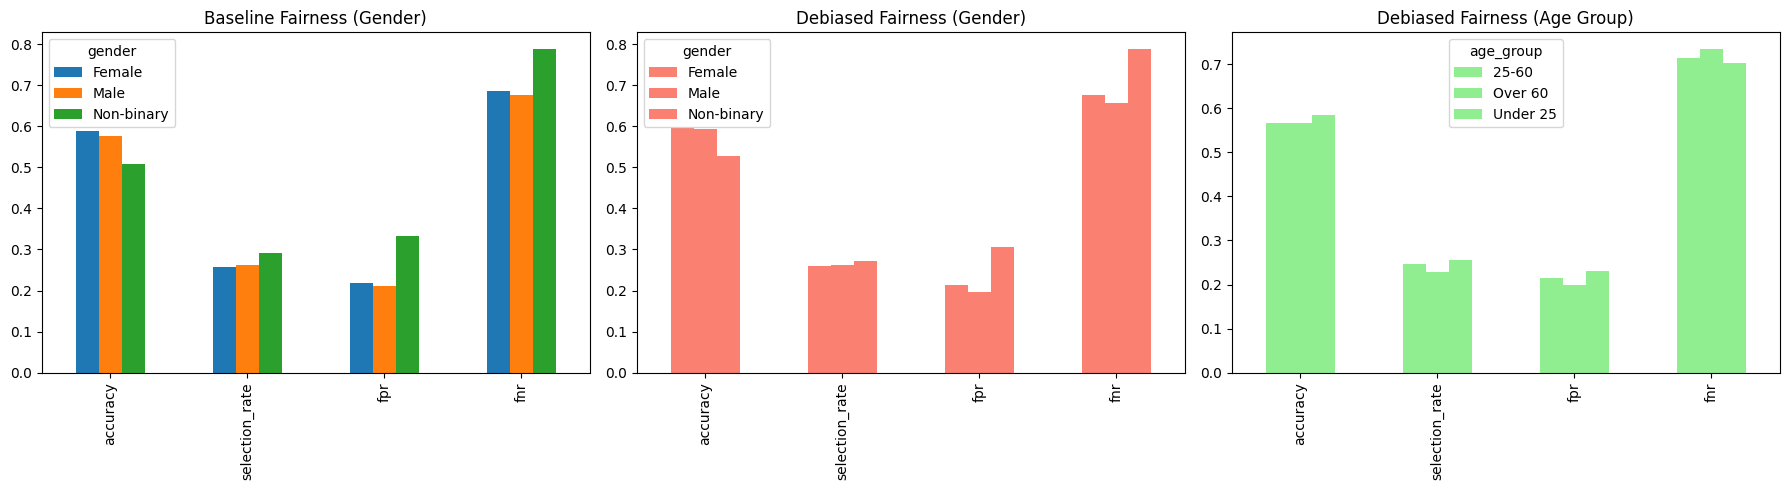

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

mf.by_group.T.plot(kind="bar", ax=ax[0])
ax[0].set_title("Baseline Fairness (Gender)")

mf_fair.by_group.T.plot(kind="bar", color="salmon", ax=ax[1])
ax[1].set_title("Debiased Fairness (Gender)")

mf_age_fair.by_group.T.plot(kind="bar", color="lightgreen", ax=ax[2])
ax[2].set_title("Debiased Fairness (Age Group)")

plt.tight_layout()
plt.show()


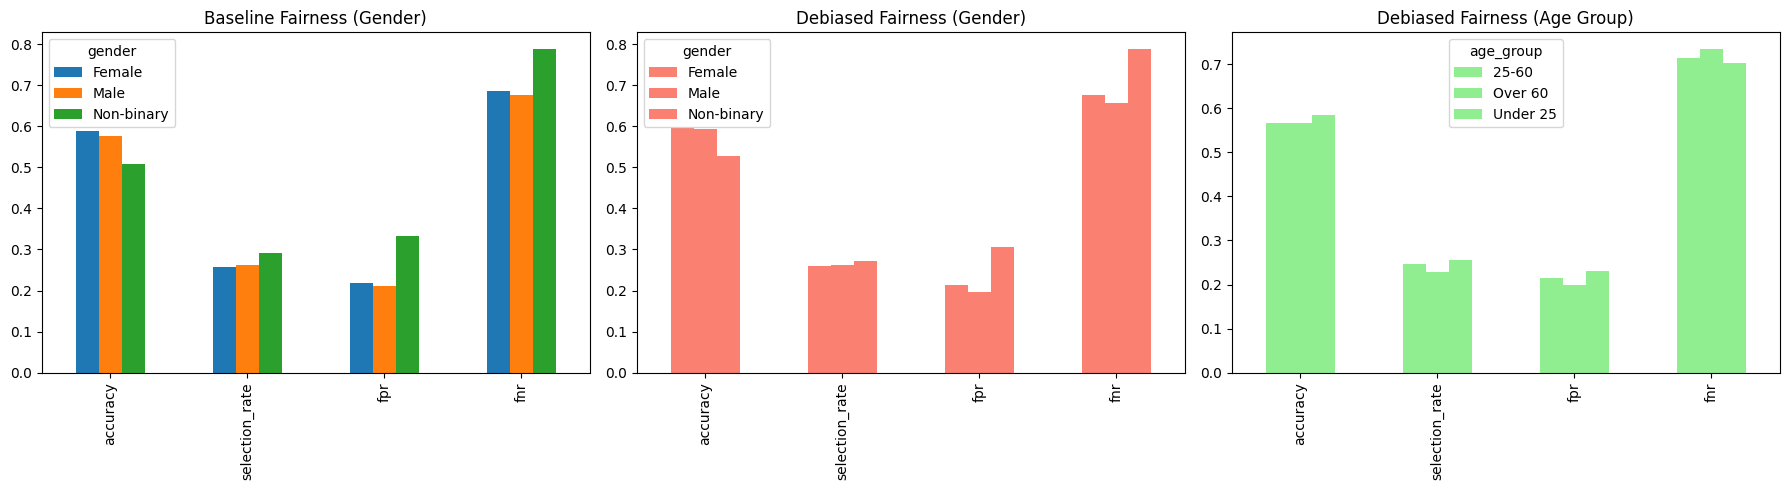

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

mf.by_group.T.plot(kind="bar", ax=ax[0])
ax[0].set_title("Baseline Fairness (Gender)")

mf_fair.by_group.T.plot(kind="bar", color="salmon", ax=ax[1])
ax[1].set_title("Debiased Fairness (Gender)")

mf_age_fair.by_group.T.plot(kind="bar", color="lightgreen", ax=ax[2])
ax[2].set_title("Debiased Fairness (Age Group)")

plt.tight_layout()
plt.show()


In [18]:
from fairlearn.reductions import GridSearch, EqualizedOdds


## Summary

In this notebook, we mitigate bias and add practical privacy protections for responsible AI in loan approval.

### Key Updates
- Sensitive attribute mitigated: gender
- Fairness constraint: Demographic Parity
- Mitigation algorithm: ExponentiatedGradient (Fairlearn)
- Base estimator: DP logistic regression (privacy-aware)
- Data minimization: encoded gender/race/zip features removed from model inputs

### Outcome Interpretation
- Fairness disparity should reduce across sensitive groups.
- Accuracy may decrease slightly due to fairness and privacy constraints.
- This is an expected fairness-privacy-utility trade-off.

### Artifacts
- results/model_debiased_xgb.pkl
- results/debiased_model_features.pkl
- results/debiased_predictions.csv

### Privacy-by-default Note
For sharing predictions, export only labels by default (y_true, y_pred).
Include probabilities (y_prob) only when explicitly needed for analysis.

Responsible AI is a continuous process: monitor fairness, privacy risk, and model performance after deployment.